In [3]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as colors
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [4]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

# Prepare Data

In [5]:
name = "netsci2025"
ehg = EmpiricalHyperGraph(name)
file = "./net_data/netsci2025/Registrations_NetSci2025_2025_April_01_h10_13.xlsx"
pd = pandas.read_excel(file)

Please check the name~
Construct netsci2025 hypergraph with 0 nodes, 0 hyperedges and all possible k is [].


In [4]:
print(pd)

      id  account_id kg_remarks  kg_confirm  kg_status  kg_total_amount  \
0      1           4        NaN           1          0                1   
1      2          12        NaN           1          0              460   
2      3          13        NaN           1          0              460   
3      4          14        NaN           1          0              470   
4      5          17        NaN           1          0              740   
..   ...         ...        ...         ...        ...              ...   
675  676         718        NaN           1          0                0   
676  677         704        NaN           1          0              755   
677  678         730        NaN           1          0              475   
678  679         731        NaN           1          0                0   
679  680         685        NaN           1          0              400   

     invoice_number kg_payment_status kg_payment_remarks first_name  ...  \
0                 1    

In [31]:
def preprocess(ehg, pd, filterby=None):
    register_satellite = dict()
    satellites = dict()
    sateid_map_name = dict()
    satellite_id = 0
    meta = dict()
    for rid, _satellite_names, _satellite_abbrs  in zip(pd["id"], pd["chosen_satellite_events_1"], pd["chosen_satellite_events"]):
        # print(rid,  _satellite_names, _satellite_abbrs)
        if type(_satellite_names) is str:
            _satellite_names=_satellite_names.split(',')
            _satellite_abbrs=_satellite_abbrs.split(',')
            if filterby is not None:
                is_filtered = False
                for _satellite_name, _satellite_abbr in zip(_satellite_names, _satellite_abbrs):
                    if _satellite_name == "half18":
                        _satellite_name = "NetSciEd"
                    if _satellite_name == "Patient wellbeing":
                        _satellite_name = "Net4Health"
                    # if one of interested sate is filtered, skip the register
                    if _satellite_name not in filterby:
                        # print(f"There are some satellites interested by {rid} filtered, skip this register.")
                        is_filtered = True
                        break
                if is_filtered:
                    continue
            # print(_satellite_names)
            # if len(_satellite_names) == 0:
            #     print(f"{rid} no interested sate")
            #     continue
            if rid not in register_satellite:
                register_satellite[rid] = []
            for _satellite_name, _satellite_abbr in zip(_satellite_names, _satellite_abbrs):
                if _satellite_name == "half18":
                    _satellite_name = "NetSciEd"
                if _satellite_name == "Patient wellbeing":
                    _satellite_name = "Net4Health"
                if _satellite_abbr not in satellites:
                    satellites[_satellite_abbr] = {"id": satellite_id, "name":_satellite_name}
                    sateid_map_name[satellite_id] = _satellite_name
                    meta[satellite_id] = _satellite_name
                    satellite_id += 1
                register_satellite[rid].append(satellites[_satellite_abbr]["id"])
    print(satellites)
    # print(register_satellite)
    data = []
    row_ind = []
    col_ind = []
    column_id = 0
    registerid_map_columnid = dict()
    Ks = []
    for rid in register_satellite.keys():
        # # if one of interested sate is filtered, skip the register
        # if filterby is not None:
        #     is_filtered = False
        #     for sate_id in register_satellite[rid]:
        #         if sateid_map_name[sate_id] not in filterby:
        #             print(f"There are some satellites interested by {rid} filtered, skip this register.")
        #             is_filtered = True
        #             break
        #     if is_filtered:
        #         continue
        if len(register_satellite[rid]) > 1: # hyperedge with order >= 2
            if rid not in registerid_map_columnid.keys():
                registerid_map_columnid[rid] = column_id
                column_id += 1
            if len(register_satellite[rid]) not in Ks:
                Ks.append(len(register_satellite[rid]))
            for sid in register_satellite[rid]:
                row_ind.append(sid)
                col_ind.append(registerid_map_columnid[rid])
                data.append(1)
    ehg.H = csr_array((data, (row_ind, col_ind)))
    ehg.n = satellite_id
    ehg.e = column_id
    ehg.Ks = Ks
    ehg.meta = meta
    print(f'Construct {name} hypergraph with {ehg.n} nodes, {ehg.e} hyperedges and all possible k is {sorted(ehg.Ks)}.')
    return ehg

In [32]:
ehg = preprocess(ehg, pd, filterby=None)

{'full08': {'id': 0, 'name': 'FLSCN  (Supply Chain)'}, 'half01': {'id': 1, 'name': 'Women in Network Science'}, 'half03': {'id': 2, 'name': 'FinEcoNets'}, 'full03': {'id': 3, 'name': 'NetBioMed'}, 'full04': {'id': 4, 'name': 'Network Neuroscience'}, 'full06': {'id': 5, 'name': 'Network Geometry'}, 'half06': {'id': 6, 'name': 'Physical networks'}, 'half07': {'id': 7, 'name': 'Criminal Complexity'}, 'half08': {'id': 8, 'name': 'Modelling dynamic networks'}, 'half13': {'id': 9, 'name': 'Sustainable Developments Goals'}, 'half10': {'id': 10, 'name': 'Science of Connections: Urban Mobility and Health'}, 'full01': {'id': 11, 'name': 'Science of Science'}, 'full02': {'id': 12, 'name': 'HONS(Higher Order and AI)'}, 'full05': {'id': 13, 'name': 'Software and Data to support Network Science'}, 'half16': {'id': 14, 'name': 'Algorithmic fairness'}, 'full07': {'id': 15, 'name': 'TENET (Temporal and Evolving Networks)'}, 'half15': {'id': 16, 'name': 'FRIENDS (signed edges)'}, 'half11': {'id': 17, 'n

In [33]:
givenNumGroup = 3
only_assortative = True
# consider_ks = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
consider_ks = None
dc = False
addition = ""
path_name = f'{name}_{f"given_{givenNumGroup}" if givenNumGroup is not None else ""}_{addition}'
save_path = f'./result/hyperEmpirical/{path_name}_BHPartition.pkl'
visual_path = f'./result/hyperEmpirical/{path_name}_ViewOfPartition.txt'
partition, _ = cd(ehg, save_path=save_path, visual_path=visual_path,
                      givenNumGroup=givenNumGroup, only_assortative=only_assortative, consider_ks=consider_ks,
                      dc=dc)
print(partition)

{2: 102, 3: 81, 4: 85, 5: 77, 6: 51, 7: 36, 8: 22, 9: 23, 10: 10, 11: 5, 12: 8, 13: 1, 14: 4, 15: 3, 18: 2, 21: 1, 25: 1, 28: 2}


Construct $BH_24.16017975335212$: 100%|███████████████████████████████████████████████| 18/18 [00:00<00:00, 661.69it/s]

EVECs construct: 0.02920365333557129
Bethe Hessian detect 3 communities in network netsci2025
[0 1 0 2 2 2 2 1 2 1 1 1 2 1 1 2 2 1 2 2 2 2 2 1 1 0 0 1]



D:\BackProgram\Anaconda\envs\network\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


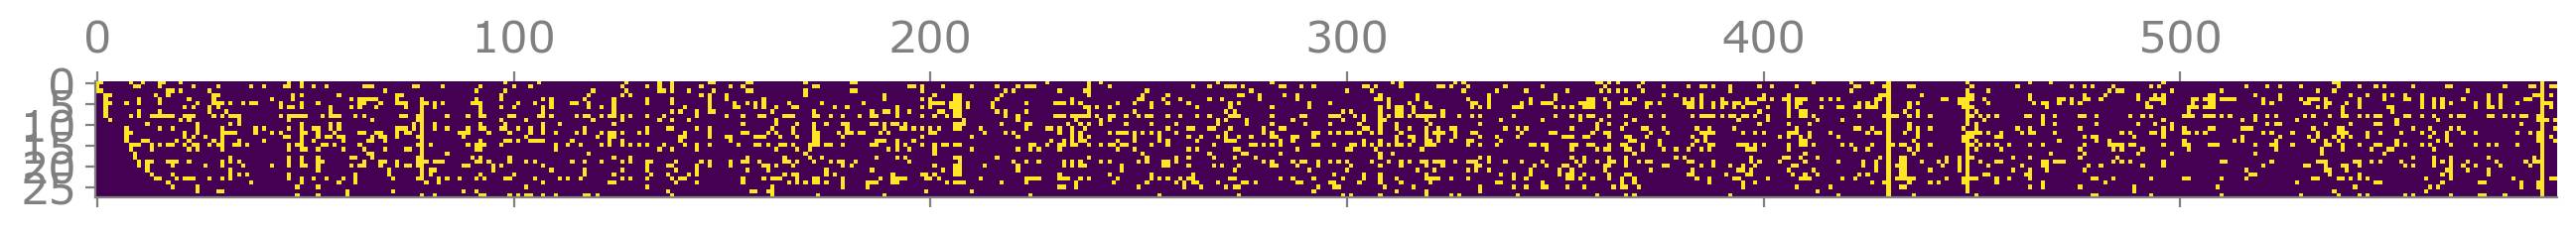

In [20]:
plt.matshow(ehg.H.toarray())

# Filter satellite

In [41]:
sate_2nd = ["Science of Science", "HONS(Higher Order and AI)", "NetBioMed", "Network Neuroscience", "Software and Data to support Network Science", 
           "TENET (Temporal and Evolving Networks)", "DAGshop", "Women in Network Science", "CPIN (Critical Phenomena in Networks)", 
           "Sustainable Developments Goals", "NetRG (Renomalization)", "Physical networks", "Science of Connections: Urban Mobility and Health", 
           "Net4Health"]
ehg_2nd = preprocess(ehg, pd, filterby=sate_2nd)

{'half10': {'id': 0, 'name': 'Science of Connections: Urban Mobility and Health'}, 'full04': {'id': 1, 'name': 'Network Neuroscience'}, 'full07': {'id': 2, 'name': 'TENET (Temporal and Evolving Networks)'}, 'half12': {'id': 3, 'name': 'CPIN (Critical Phenomena in Networks)'}, 'full02': {'id': 4, 'name': 'HONS(Higher Order and AI)'}, 'full05': {'id': 5, 'name': 'Software and Data to support Network Science'}, 'half01': {'id': 6, 'name': 'Women in Network Science'}, 'half06': {'id': 7, 'name': 'Physical networks'}, 'half05': {'id': 8, 'name': 'NetRG (Renomalization)'}, 'full01': {'id': 9, 'name': 'Science of Science'}, 'half13': {'id': 10, 'name': 'Sustainable Developments Goals'}, 'half11': {'id': 11, 'name': 'Net4Health'}, 'full03': {'id': 12, 'name': 'NetBioMed'}, 'half02': {'id': 13, 'name': 'DAGshop'}}
Construct netsci2025 hypergraph with 14 nodes, 33 hyperedges and all possible k is [2, 3, 4, 5].


In [42]:
givenNumGroup = 3
only_assortative = True
# consider_ks = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
consider_ks = None
dc = False
addition = ""
path_name = f'{name}_June2nd_{f"given_{givenNumGroup}" if givenNumGroup is not None else ""}_{addition}'
save_path = f'./result/hyperEmpirical/{path_name}_BHPartition.pkl'
visual_path = f'./result/hyperEmpirical/{path_name}_ViewOfPartition.txt'
partition, _ = cd(ehg_2nd, save_path=save_path, visual_path=visual_path,
                      givenNumGroup=givenNumGroup, only_assortative=only_assortative, consider_ks=consider_ks,
                      dc=dc)
print(partition)

{2: 18, 3: 7, 4: 7, 5: 1}


Construct $BH_3.605551275463989$: 100%|█████████████████████████████████████████████████| 4/4 [00:00<00:00, 799.79it/s]

EVECs construct: 0.011001348495483398
Bethe Hessian detect 3 communities in network netsci2025
[1 1 2 2 1 0 0 1 2 0 0 1 1 0]



D:\BackProgram\Anaconda\envs\network\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [44]:
sate_3rd = ["Network Geometry", "FLSCN  (Supply Chain)", "SINM (Stat Inference for Network Models)", "TopoNets", "Criminal Complexity", 
           "HISTONET", "EpiMob", "NetSciEd", "Algorithmic fairness", "FinEcoNets", "Understudied Networks in Computational Social Science", 
           "MIX-NEXT (Multiscale networks)", "FRIENDS (signed edges)"]
ehg_3rd = preprocess(ehg, pd, filterby=sate_3rd)

{'full08': {'id': 0, 'name': 'FLSCN  (Supply Chain)'}, 'half03': {'id': 1, 'name': 'FinEcoNets'}, 'full06': {'id': 2, 'name': 'Network Geometry'}, 'half16': {'id': 3, 'name': 'Algorithmic fairness'}, 'full09': {'id': 4, 'name': 'SINM (Stat Inference for Network Models)'}, 'half17': {'id': 5, 'name': 'Understudied Networks in Computational Social Science'}, 'full10': {'id': 6, 'name': 'TopoNets'}, 'half04': {'id': 7, 'name': 'HISTONET'}, 'half18': {'id': 8, 'name': 'NetSciEd'}, 'half09': {'id': 9, 'name': 'EpiMob'}, 'half14': {'id': 10, 'name': 'MIX-NEXT (Multiscale networks)'}, 'half15': {'id': 11, 'name': 'FRIENDS (signed edges)'}, 'half07': {'id': 12, 'name': 'Criminal Complexity'}}
Construct netsci2025 hypergraph with 13 nodes, 25 hyperedges and all possible k is [2, 3, 4].


In [45]:
givenNumGroup = 3
only_assortative = True
# consider_ks = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
consider_ks = None
dc = False
addition = ""
path_name = f'{name}_June3rd_{f"given_{givenNumGroup}" if givenNumGroup is not None else ""}_{addition}'
save_path = f'./result/hyperEmpirical/{path_name}_BHPartition.pkl'
visual_path = f'./result/hyperEmpirical/{path_name}_ViewOfPartition.txt'
partition, _ = cd(ehg_3rd, save_path=save_path, visual_path=visual_path,
                      givenNumGroup=givenNumGroup, only_assortative=only_assortative, consider_ks=consider_ks,
                      dc=dc)
print(partition)

{2: 16, 3: 8, 4: 1}


Construct $BH_2.6602486870447053$: 100%|████████████████████████████████████████████████| 3/3 [00:00<00:00, 591.50it/s]

EVECs construct: 0.008338212966918945
Bethe Hessian detect 3 communities in network netsci2025
[0 0 1 1 1 2 1 2 2 2 1 2 0]



D:\BackProgram\Anaconda\envs\network\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
